# **Electricity Price Forecasting in Restructured Power Systems**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot style
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("Final_dataset.csv")

# Convert timestamp and sort
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['country', 'timestamp']).reset_index(drop=True)

# **EDA**

In [4]:
df.head()

,timestamp,country,price,load_actual,load_forecast,solar_forecast,solar_actual,wind_forecast,wind_actual,re_penetration
0,2025-01-01 01:00:00,BE,10.27,7746.7775,8217.6550,0.0,0.0,2156.28,1920.23,0.247875
1,2025-01-01 02:00:00,BE,8.38,7476.8925,8000.2200,0.0,0.0,2174.63,2102.19,0.281158
2,2025-01-01 03:00:00,BE,6.61,7227.7350,7830.1175,0.0,0.0,2190.33,1991.09,0.275479
3,2025-01-01 04:00:00,BE,2.29,7164.3200,7726.2650,0.0,0.0,2195.38,2036.87,0.284308
4,2025-01-01 05:00:00,BE,3.01,7177.0475,7671.9725,0.0,0.0,2196.13,2002.39,0.278999


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (16942, 10)

Columns:
Index(['timestamp', 'country', 'price', 'load_actual', 'load_forecast',
       'solar_forecast', 'solar_actual', 'wind_forecast', 'wind_actual',
       're_penetration'],
      dtype='object')

Data Types:
timestamp         datetime64[ns]
country                   object
price                    float64
load_actual              float64
load_forecast            float64
solar_forecast           float64
solar_actual             float64
wind_forecast            float64
wind_actual              float64
re_penetration           float64
dtype: object


In [6]:
print(df['timestamp'].min())
print(df['timestamp'].max())

2025-01-01 01:00:00
2025-12-19 23:00:00


In [7]:
print(df.isnull().sum())

timestamp         0
country           0
price             0
load_actual       0
load_forecast     0
solar_forecast    0
solar_actual      0
wind_forecast     0
wind_actual       0
re_penetration    0
dtype: int64


In [8]:
df.describe()

,timestamp,price,load_actual,load_forecast,solar_forecast,solar_actual,wind_forecast,wind_actual,re_penetration
count,16942,16942.000000,16942.000000,16942.000000,16942.000000,16942.000000,16942.000000,16942.000000,16942.000000
mean,2025-06-26 12:00:00,93.100584,7447.280242,7443.560184,1414.001385,1270.676041,910.155564,907.812362,0.312948
min,2025-01-01 01:00:00,-462.330000,3207.000000,3154.000000,0.000000,0.000000,2.380000,0.640000,0.000060
25%,2025-03-30 06:15:00,68.320000,5639.000000,5672.125000,0.000000,0.000000,308.000000,286.720000,0.088394
50%,2025-06-26 12:00:00,94.600000,7381.171250,7410.070000,96.000000,70.000000,655.950000,681.000000,0.225316
75%,2025-09-22 17:45:00,120.660000,9109.100000,9141.559375,2505.660000,2259.000000,1299.000000,1328.870000,0.493735
max,2025-12-19 23:00:00,517.570000,13031.412500,12590.595000,7874.700000,7726.270000,3471.000000,3567.000000,1.238073
std,NaN,54.404926,2149.311061,2112.970563,2028.175669,1816.575729,781.571259,775.374428,0.270549


In [9]:
# Country-wise Price Analysis
country_stats = df.groupby('country')['price'].agg(['mean', 'std', 'min', 'max'])
country_stats

,mean,std,min,max
country,,,,
BE,82.541331,48.325803,-462.33,517.5700
GR,103.659837,57.980480,-50.00,478.9125


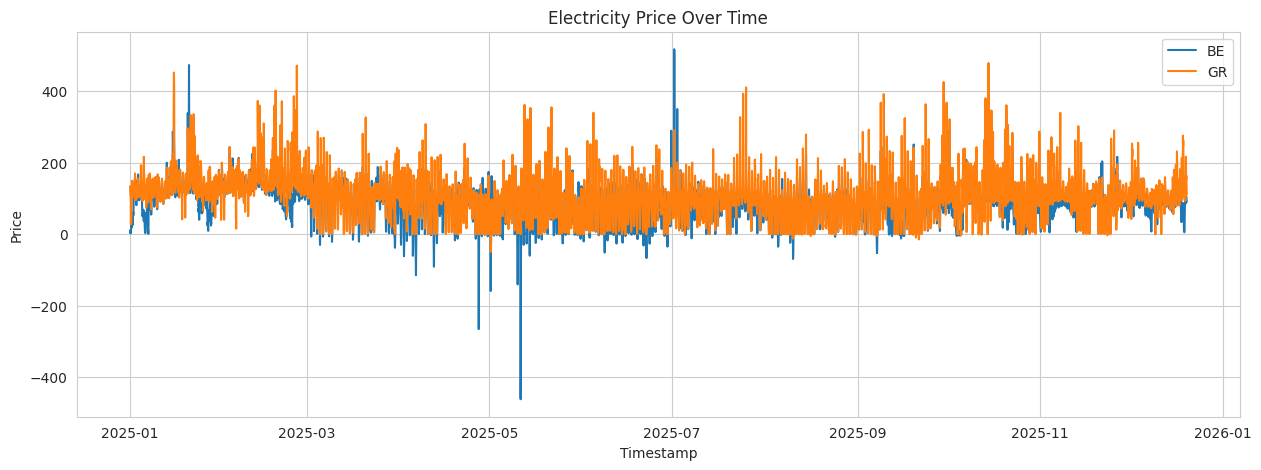

In [10]:
plt.figure(figsize=(15,5))

for country, temp in df.groupby('country'):
    plt.plot(temp['timestamp'], temp['price'], label=country)

plt.title("Electricity Price Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()

plt.savefig("Price over time.png")
plt.show()

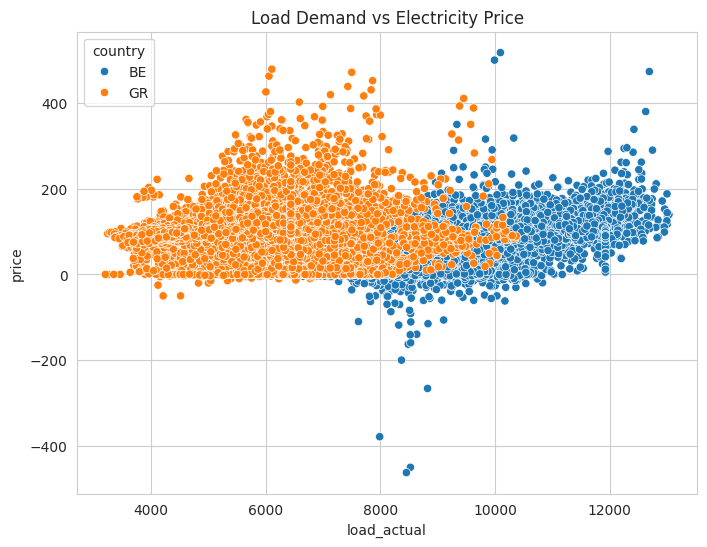

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='load_actual',y='price',hue='country')
plt.title("Load Demand vs Electricity Price")
plt.savefig("Load demand vs electricity.png")
plt.show()

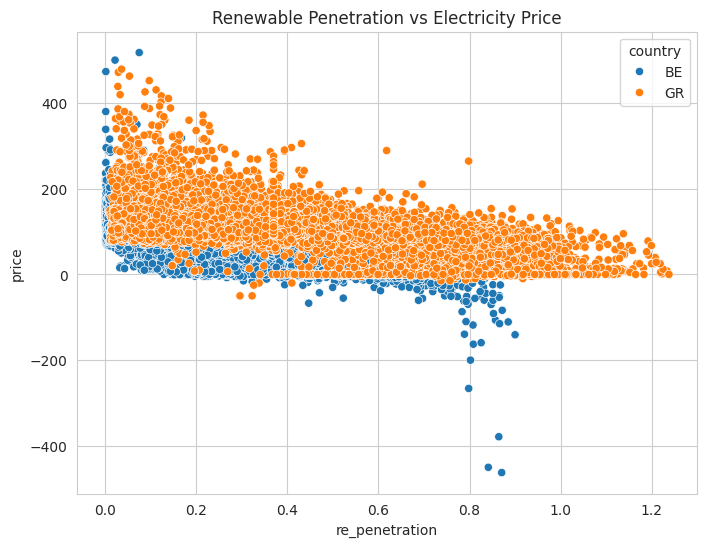

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='re_penetration',y='price',hue='country')
plt.title("Renewable Penetration vs Electricity Price")
plt.savefig("Renewable_penetration_vs_price.png")
plt.show()

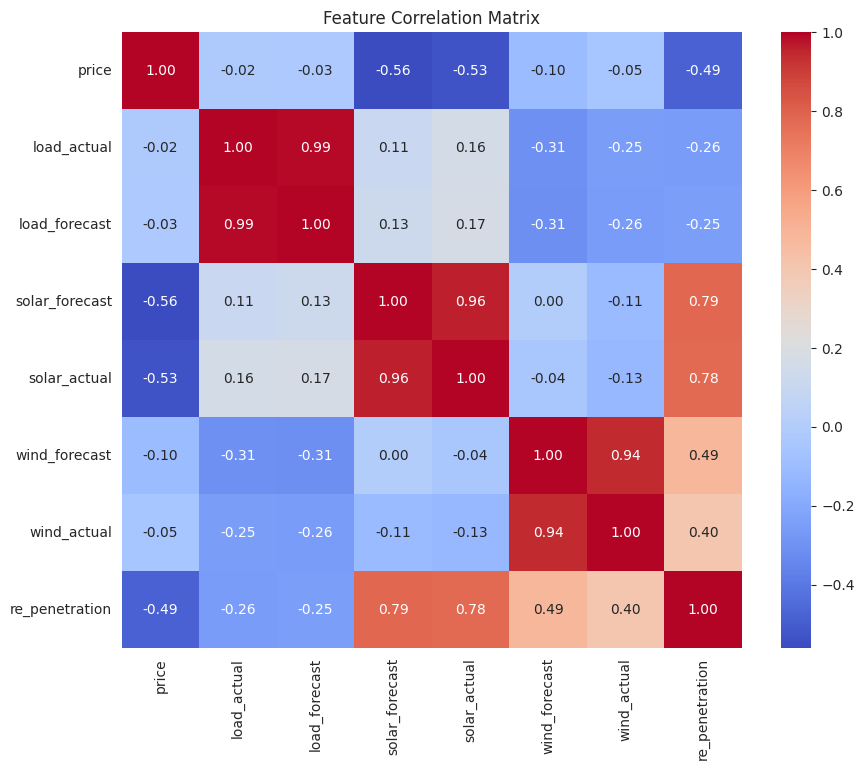

In [13]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

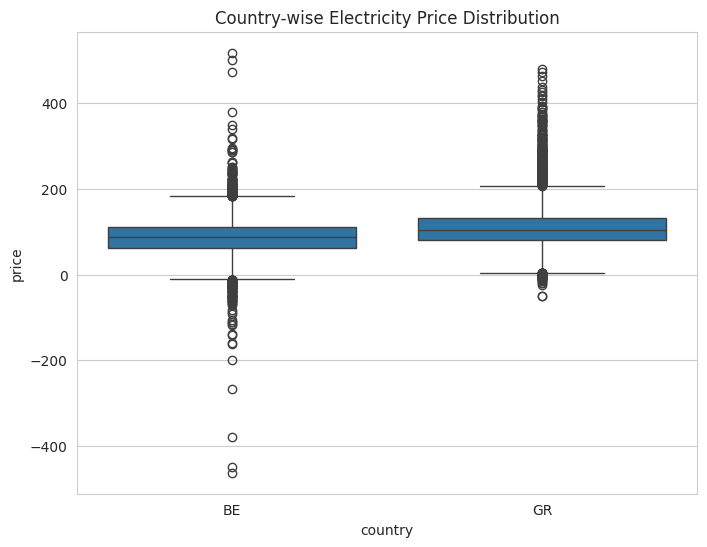

In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='country',y='price')
plt.title("Country-wise Electricity Price Distribution")
plt.savefig("price_trend.png")
plt.show()

# **Feature Engineering**

In [15]:
# Temporal Features
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

In [16]:
# Lag Features
df['price_lag_1'] = df.groupby('country')['price'].shift(1)
df['price_lag_24'] = df.groupby('country')['price'].shift(24)

In [17]:
# Weekly Lag Feature
df['price_lag_168'] = (df.groupby('country')['price'].shift(168))

In [18]:
# Rolling Mean Features
df['price_roll_3'] = df.groupby('country')['price'].transform(lambda x: x.shift(1).rolling(3).mean())
df['price_roll_6'] = df.groupby('country')['price'].transform(lambda x: x.shift(1).rolling(6).mean())
df['price_roll_12'] = df.groupby('country')['price'].transform(lambda x: x.shift(1).rolling(12).mean())
df['price_std_24'] = df.groupby('country')['price'].transform(lambda x: x.shift(1).rolling(24).std())

In [19]:
# Load Ramp Feature
df['load_ramp'] = (df.groupby('country')['load_actual'].diff())

In [20]:
# Cyclical Hour Encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

In [21]:
# Country Encoding
df_model = pd.get_dummies(df,columns=['country'],drop_first=True)

In [22]:
# Remove Missing Values Created by Lag/Rolling Features
print("Before dropna:", df_model.shape)
df_model = df_model.dropna()
print("After dropna:", df_model.shape)

Before dropna: (16942, 24)
After dropna: (16606, 24)


In [23]:
df_model.to_csv("features_dataset.csv", index=False)


# **Baseline Model - Linear Reggression**

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

In [25]:
# Target Variable
y = df_model['price']

# Feature Columns
X = df_model.drop(columns=['price', 'timestamp'])

In [26]:
# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    print(f"Fold {fold+1}")
    print("Train Shape:", X_train.shape)
    print("Test Shape :", X_test.shape)

# Using the final fold as train-test split
print("\nTraining Linear Regression on Final Fold...")

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Fold 1
Train Shape: (2771, 22)
Test Shape : (2767, 22)
Fold 2
Train Shape: (5538, 22)
Test Shape : (2767, 22)
Fold 3
Train Shape: (8305, 22)
Test Shape : (2767, 22)
Fold 4
Train Shape: (11072, 22)
Test Shape : (2767, 22)
Fold 5
Train Shape: (13839, 22)
Test Shape : (2767, 22)

Training Linear Regression on Final Fold...


In [27]:
# Model Training
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression Results")
print("MAE :", round(mae, 4))
print("RMSE :", round(rmse, 4))
print("R² Score :", round(r2, 4))

# Save Predictions
pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

pred_df.to_csv("predictions_lr.csv", index=False)


Linear Regression Results
MAE : 14.3721
RMSE : 22.6087
R² Score : 0.8448


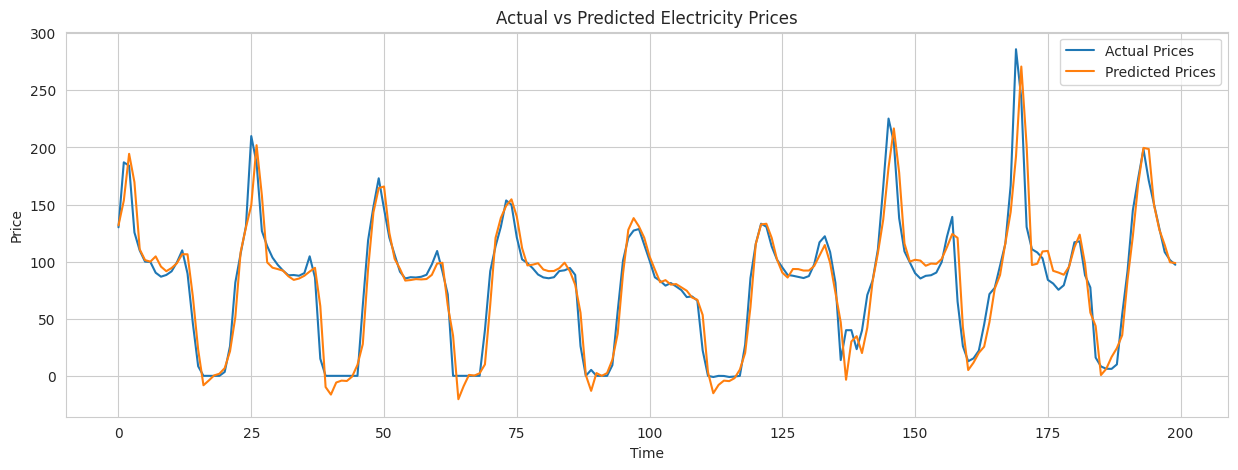

In [28]:
# Visualization
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:200], label='Actual Prices')
plt.plot(y_pred[:200], label='Predicted Prices')

plt.title("Actual vs Predicted Electricity Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.savefig("lr_predictions.png")
plt.show()

# **Random Forest**

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Results")
print(f"MAE : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R² Score : {rf_r2:.4f}")

# Save Predictions
rf_pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

rf_pred_df.to_csv("predictions_rf.csv", index=False)


Random Forest Results
MAE : 13.6704
RMSE : 22.3467
R² Score : 0.8484


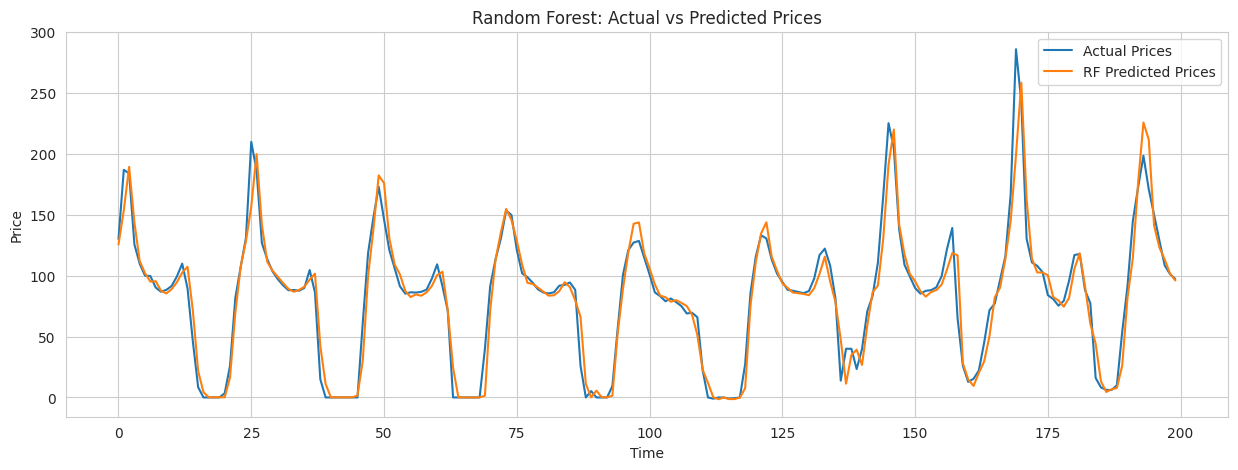

In [30]:
# Actual vs Predicted Plot
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:200], label='Actual Prices')
plt.plot(rf_pred[:200], label='RF Predicted Prices')

plt.title("Random Forest: Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.savefig("rf_predictions.png")
plt.show()

In [31]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
    })
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance.head(10))

           Feature  Importance
11     price_lag_1    0.851961
12    price_lag_24    0.037775
19        hour_sin    0.026824
18       load_ramp    0.011160
3     solar_actual    0.009493
2   solar_forecast    0.009397
14    price_roll_3    0.006941
13   price_lag_168    0.006267
6   re_penetration    0.005374
7             hour    0.005267


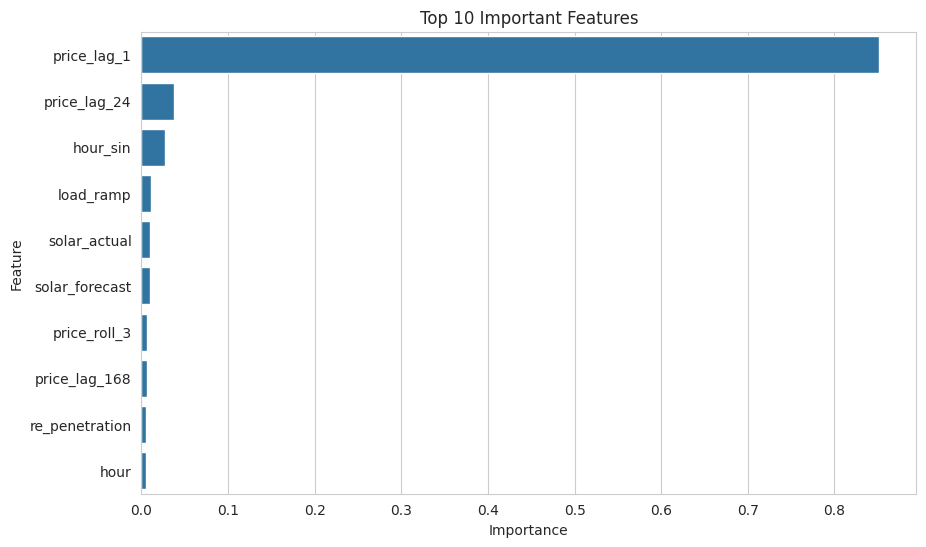

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10),x='Importance',y='Feature')
plt.title("Top 10 Important Features")
plt.show()

# **XGBoost**

In [33]:
from xgboost import XGBRegressor

# XGBoost Model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train XGBoost
xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluation Metrics
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R2 Score : {xgb_r2:.4f}")


MAE  : 12.56
RMSE : 20.42
R2 Score : 0.8735


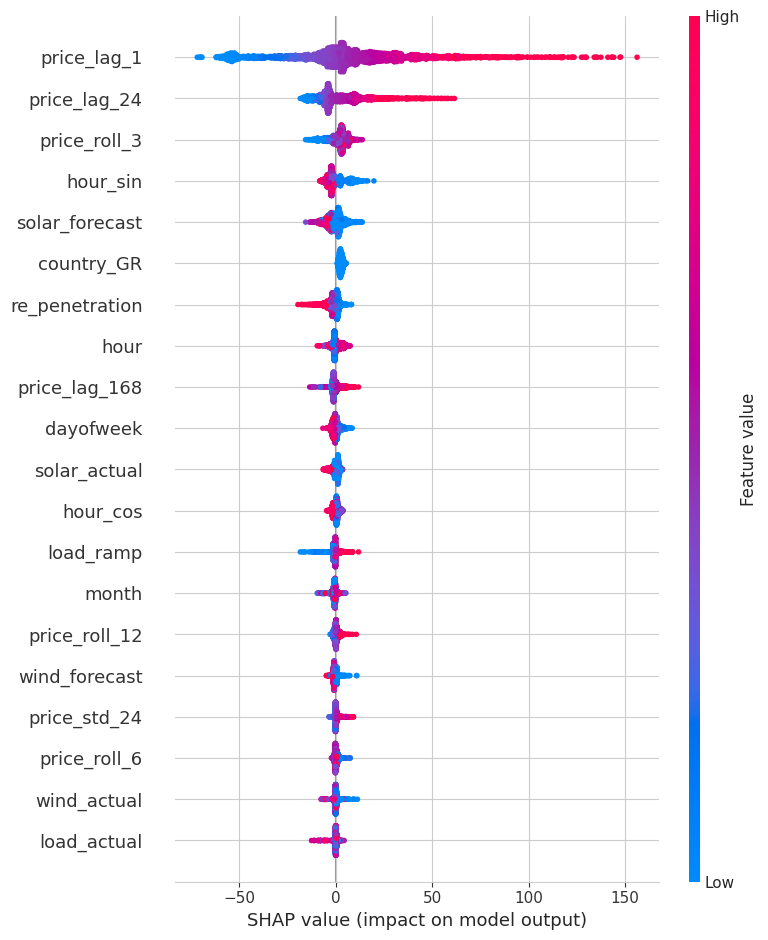

In [34]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [35]:
xgb_pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': xgb_pred
})

xgb_pred_df.to_csv("predictions_xgb.csv", index=False)

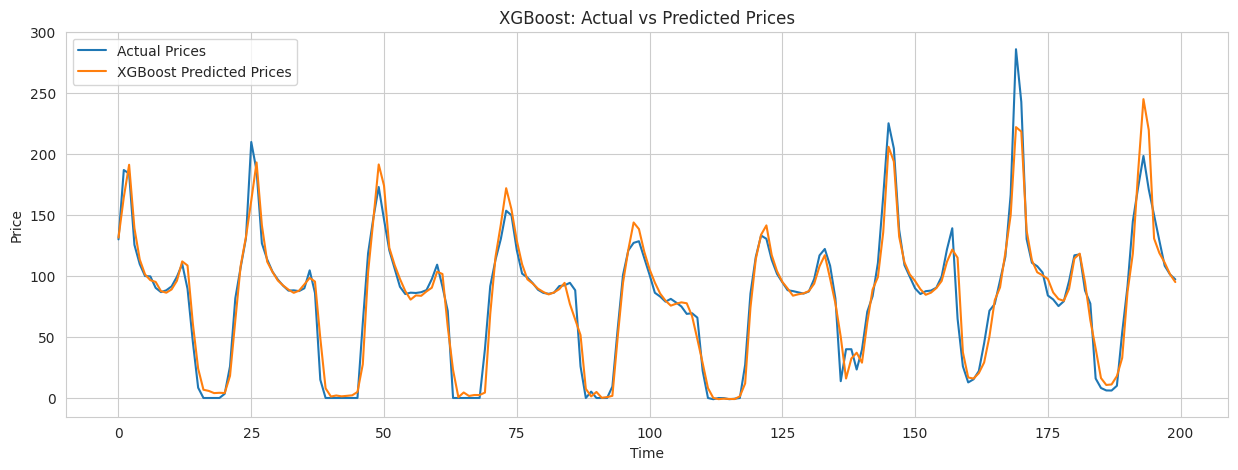

In [36]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:200],label='Actual Prices')

plt.plot( xgb_pred[:200],label='XGBoost Predicted Prices')

plt.title("XGBoost: Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.show()

In [37]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by='Importance',ascending=False)
xgb_importance.head(10)

,Feature,Importance
11,price_lag_1,0.355512
12,price_lag_24,0.245056
14,price_roll_3,0.113917
19,hour_sin,0.051340
3,solar_actual,0.024376
2,solar_forecast,0.024018
7,hour,0.022495
20,hour_cos,0.020869
18,load_ramp,0.016403
13,price_lag_168,0.014886


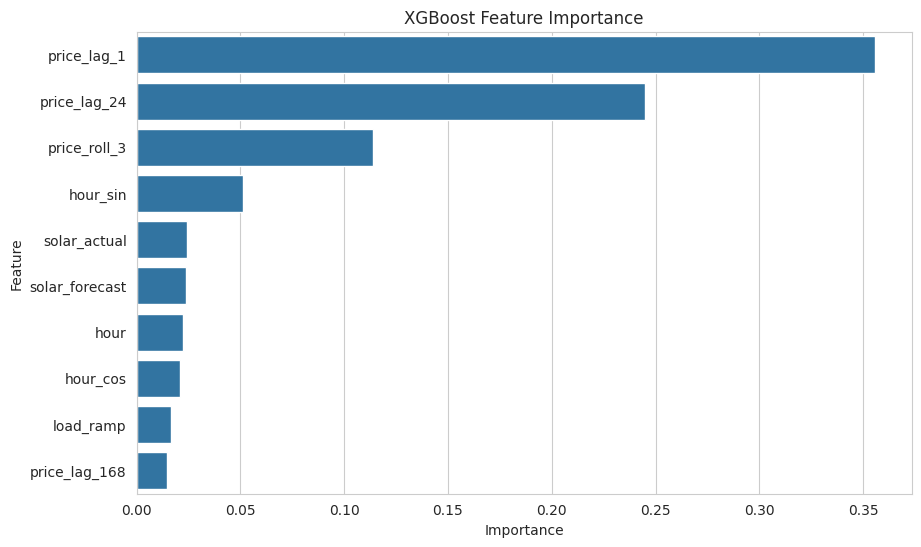

In [38]:
plt.figure(figsize=(10,6))
sns.barplot( data=xgb_importance.head(10),x='Importance',y='Feature')
plt.title("XGBoost Feature Importance")
plt.show()

**Model Comparision**

In [39]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae, rf_mae, xgb_mae],
    'RMSE': [rmse, rf_rmse, xgb_rmse],
    'R2 Score': [r2, rf_r2, xgb_r2]
})

comparison_df
comparison_df.to_csv("model_comparision.csv", index=False)

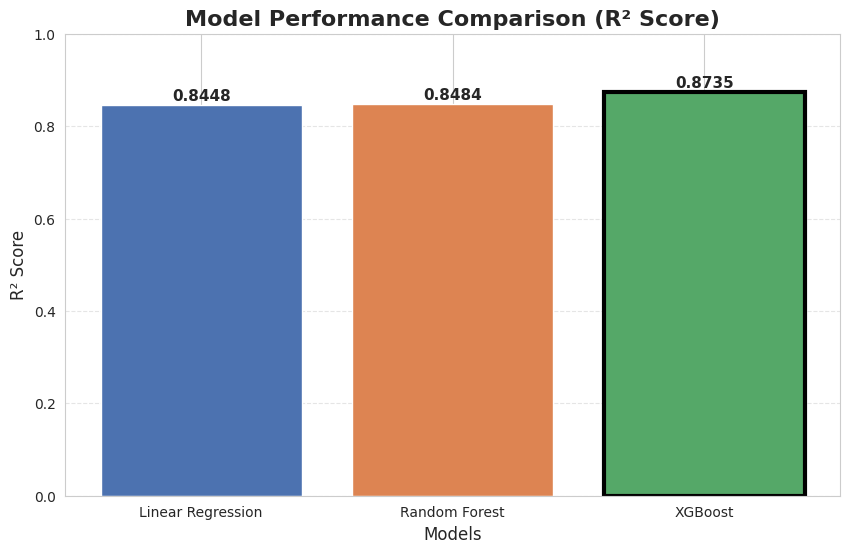

In [40]:
plt.figure(figsize=(10,6))

colors = ['#4C72B0', '#DD8452', '#55A868']
bars = plt.bar(
    comparison_df['Model'],
    comparison_df['R2 Score'],
    color=colors
)

# Value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.4f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Highlight best model
best_index = comparison_df['R2 Score'].idxmax()
bars[best_index].set_edgecolor('black')
bars[best_index].set_linewidth(3)

plt.title(
    "Model Performance Comparison (R² Score)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Models", fontsize=12)
plt.ylabel("R² Score", fontsize=12)

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig("model_comparison_r2.png")
plt.show()

# HyperParameter Tuning for XGBoost

In [41]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

tscv_tuning = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=tscv_tuning,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_
best_pred = best_xgb.predict(X_test)

best_mae = mean_absolute_error(y_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2 = r2_score(y_test, best_pred)

print(f"MAE  : {best_mae:.2f}")
print(f"RMSE : {best_rmse:.2f}")
print(f"R2 Score : {best_r2:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
MAE  : 13.18
RMSE : 21.50
R2 Score : 0.8597


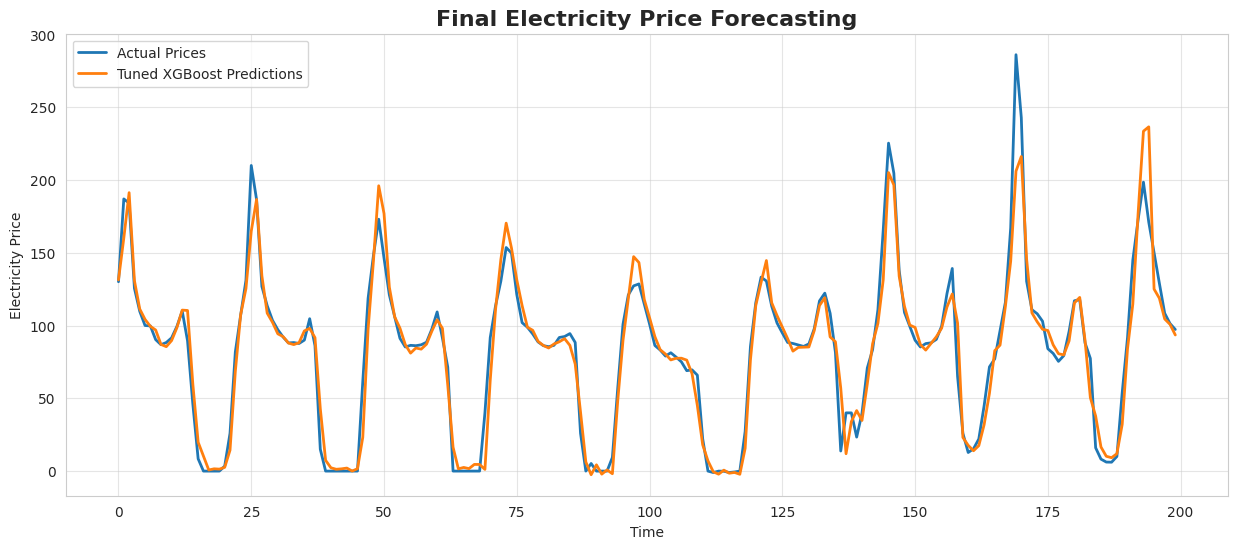

In [42]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values[:200],label='Actual Prices',linewidth=2)
plt.plot(best_pred[:200],label='Tuned XGBoost Predictions',linewidth=2)

plt.title("Final Electricity Price Forecasting",fontsize=16,fontweight='bold')
plt.xlabel("Time")
plt.ylabel("Electricity Price")

plt.legend()
plt.grid(alpha=0.5)
plt.show()

In [43]:
final_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
})

final_importance = final_importance.sort_values(by='Importance',ascending=False)
final_importance.head(10)

,Feature,Importance
11,price_lag_1,0.682326
19,hour_sin,0.082088
12,price_lag_24,0.032189
7,hour,0.025213
3,solar_actual,0.021404
20,hour_cos,0.019940
21,country_GR,0.019036
2,solar_forecast,0.015496
18,load_ramp,0.012474
6,re_penetration,0.011810


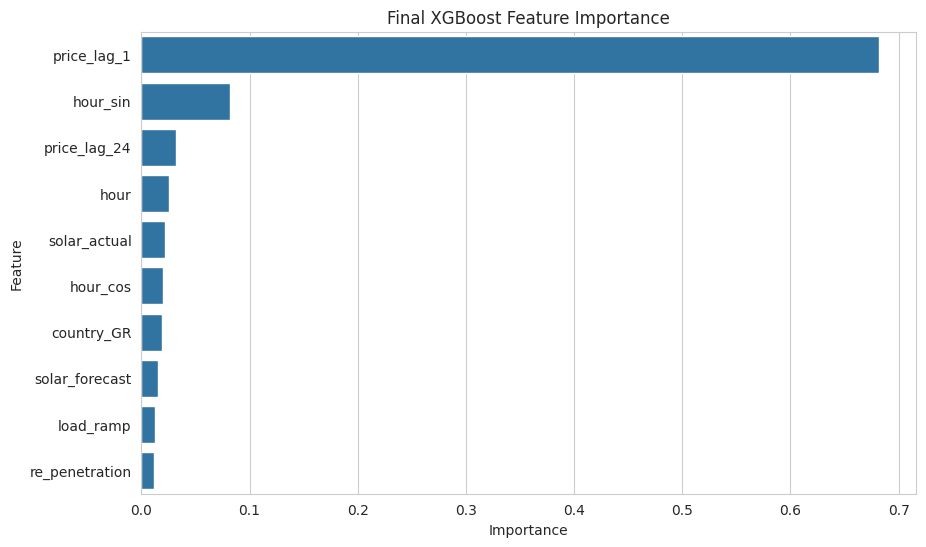

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=final_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Final XGBoost Feature Importance")
plt.savefig("final_xgb_feature_importance.png")
plt.show()

In [45]:
import joblib
joblib.dump(best_xgb, "final_xgboost_model.pkl")

['final_xgboost_model.pkl']

In [46]:
final_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_pred
})

final_results.to_csv("final_forecasting_results.csv",index=False)

# **Predictions on New Data**

In [47]:
data = {
    'timestamp': ['2025-12-20 00:00:00','2025-12-20 01:00:00','2025-12-20 02:00:00','2025-12-20 03:00:00','2025-12-20 04:00:00','2025-12-20 05:00:00','2025-12-20 06:00:00','2025-12-20 07:00:00','2025-12-20 08:00:00','2025-12-20 09:00:00','2025-12-20 10:00:00','2025-12-20 11:00:00','2025-12-20 12:00:00','2025-12-20 13:00:00','2025-12-20 14:00:00','2025-12-20 15:00:00','2025-12-20 16:00:00','2025-12-20 17:00:00','2025-12-20 18:00:00','2025-12-20 19:00:00','2025-12-20 20:00:00','2025-12-20 21:00:00','2025-12-20 22:00:00','2025-12-20 23:00:00'],
    'country': ['BE'] * 24,
    'price': [78.5,74.2,70.8,68.1,66.4,69.5,82.7,95.1,108.4,115.2,120.5,124.3,128.1,126.7,122.4,118.6,130.2,145.7,158.3,162.5,150.8,132.6,110.4,92.7],
    'load_actual': [7200,7050,6900,6750,6600,6800,7600,8300,9100,9700,10100,10400,10600,10500,10200,9900,10800,11600,12100,12300,11800,11000,9600,8500],
    'load_forecast': [7180,7000,6880,6700,6580,6760,7550,8250,9050,9650,10050,10350,10550,10450,10150,9850,10750,11550,12050,12250,11750,10950,9550,8450],
    'solar_forecast': [0,0,0,0,0,0,50,120,250,420,620,850,1020,980,900,750,500,220,50,0,0,0,0,0],
    'solar_actual': [0,0,0,0,0,0,45,110,240,400,600,830,1000,960,880,730,480,210,45,0,0,0,0,0],
    'wind_forecast': [850,870,900,920,950,980,1000,1020,980,930,900,870,840,820,800,780,760,730,700,680,650,620,600,580],
    'wind_actual': [820,860,880,910,940,960,990,1000,960,910,890,860,830,810,790,770,750,720,690,670,640,610,590,570],
    're_penetration': [0.28,0.30,0.31,0.33,0.35,0.36,0.32,0.29,0.27,0.25,0.24,0.23,0.22,0.22,0.23,0.24,0.20,0.18,0.16,0.15,0.16,0.18,0.21,0.24]
}

new_df = pd.DataFrame(data)
new_df.to_csv("new_data.csv", index=False)

print("CSV file 'new_data.csv' created successfully!")
print(new_df.head())

CSV file 'new_data.csv' created successfully!
             timestamp country  price  load_actual  load_forecast  \
0  2025-12-20 00:00:00      BE   78.5         7200           7180   
1  2025-12-20 01:00:00      BE   74.2         7050           7000   
2  2025-12-20 02:00:00      BE   70.8         6900           6880   
3  2025-12-20 03:00:00      BE   68.1         6750           6700   
4  2025-12-20 04:00:00      BE   66.4         6600           6580   

   solar_forecast  solar_actual  wind_forecast  wind_actual  re_penetration  
0               0             0            850          820            0.28  
1               0             0            870          860            0.30  
2               0             0            900          880            0.31  
3               0             0            920          910            0.33  
4               0             0            950          940            0.35  


In [48]:
model = joblib.load("final_xgboost_model.pkl")

new_df = pd.read_csv("new_data.csv")

new_df['timestamp'] = pd.to_datetime(new_df['timestamp'])
new_df = new_df.sort_values(['country', 'timestamp']).reset_index(drop=True)

# Temporal Features
new_df['hour'] = new_df['timestamp'].dt.hour
new_df['dayofweek'] = new_df['timestamp'].dt.dayofweek
new_df['month'] = new_df['timestamp'].dt.month
new_df['is_weekend'] = new_df['dayofweek'].isin([5, 6]).astype(int)

# Lag Features
new_df['price_lag_1'] = new_df.groupby('country')['price'].shift(1)

# Rolling Features
new_df['price_roll_3'] = new_df.groupby('country')['price'].transform(lambda x: x.shift(1).rolling(3).mean())
new_df['price_roll_6'] = new_df.groupby('country')['price'].transform(lambda x: x.shift(1).rolling(6).mean())

# Load Ramp
new_df['load_ramp'] = new_df.groupby('country')['load_actual'].diff()

# Cyclical Encoding
new_df['hour_sin'] = np.sin(2 * np.pi * new_df['hour'] / 24)
new_df['hour_cos'] = np.cos(2 * np.pi * new_df['hour'] / 24)

# Country Encoding
new_df = pd.get_dummies(new_df, columns=['country'], drop_first=True)

# Remove Missing Rows
new_df = new_df.dropna()

# Align Features With Training Data
X_new = new_df.drop(columns=['price', 'timestamp'])
X_new = X_new.reindex(columns=X.columns, fill_value=0)

# Predictions
new_predictions = model.predict(X_new)
new_df['Predicted_Price'] = new_predictions

# Save Results
new_df.to_csv("new_data_predictions.csv", index=False)
print(new_df[['timestamp', 'price', 'Predicted_Price']].head())

             timestamp  price  Predicted_Price
6  2025-12-20 06:00:00   82.7        69.219025
7  2025-12-20 07:00:00   95.1        83.399368
8  2025-12-20 08:00:00  108.4        83.400848
9  2025-12-20 09:00:00  115.2        66.687416
10 2025-12-20 10:00:00  120.5        72.097984


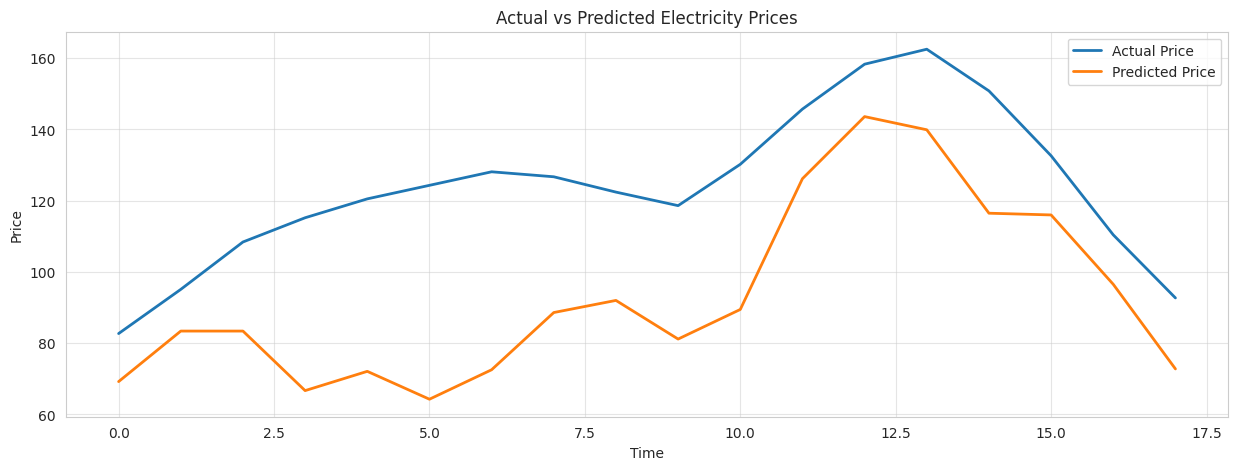

In [49]:

# Visualization
plt.figure(figsize=(15,5))
plt.plot(new_df['price'].values, label='Actual Price', linewidth=2)
plt.plot(new_df['Predicted_Price'].values, label='Predicted Price', linewidth=2)
plt.title("Actual vs Predicted Electricity Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.5)
plt.savefig("new_data_predictions_plot.png")
plt.show()